In [1]:
import numpy as np
from transformers import RobertaForMaskedLM
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
w_mag = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/BabyLM/models/mask_10Mto100M_mag/checkpoint-186340")
g_mag = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/BabyLM/models/glue/mask_10Mto100M_mag/prune_70/seed_12/qqp")
w_rand = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/BabyLM/models/mask_100M_rand/checkpoint-186340")
g_rand = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/BabyLM/models/glue/mask_100M_rand/qqp")


Some weights of RobertaForMaskedLM were not initialized from the model checkpoint at /media/anna/Samsung_T5/Initialization/BabyLM/models/glue/mask_10Mto100M_mag/prune_70/seed_12/qqp and are newly initialized: ['lm_head.bias', 'lm_head.decoder.bias', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForMaskedLM were not initialized from the model checkpoint at /media/anna/Samsung_T5/Initialization/BabyLM/models/glue/mask_100M_rand/qqp and are newly initialized: ['lm_head.bias', 'lm_head.decoder.bias', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [37]:
w_mag_masked = 0
w_mag_unmasked = 0
w_mag_total = 0

for name, param in w_mag.named_parameters():
    if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm":
        
        print(name)
        param_np = param.detach().numpy()
        for v in param_np:
            mask = sum([1 for w in v if w == 0])
            unmask = sum([1 for w in v if w != 0])
            total = sum([1 for w in v])
            
            w_mag_masked += mask
            w_mag_unmasked += unmask
            w_mag_total += total

roberta.encoder.layer.0.attention.self.query.weight
roberta.encoder.layer.0.attention.self.key.weight
roberta.encoder.layer.0.attention.self.value.weight
roberta.encoder.layer.0.attention.output.dense.weight
roberta.encoder.layer.0.intermediate.dense.weight


KeyboardInterrupt: 

In [4]:
print("masked:", w_mag_masked)
print("unmasked:", w_mag_unmasked)
print("total:", w_mag_total)

masked: 34094984
unmasked: 50839672
total: 84934656


In [ ]:
def wgt_dict_build(model, glue_model, cutoff_perc):
    wgt_dict = {"masked":dict(), "unmasked":dict()}
    glue_dict = {"masked":{"raw":dict(), "move":dict()}, "unmasked":{"raw":dict(), "move":dict()}}
    for i in range(12):
        wgt_dict["masked"][f"layer_{i}"] = dict()
        glue_dict["masked"]["raw"][f"layer_{i}"] = dict()
        glue_dict["masked"]["move"][f"layer_{i}"] = dict()
        wgt_dict["unmasked"][f"layer_{i}"] = dict()
        glue_dict["unmasked"]["raw"][f"layer_{i}"] = dict()
        glue_dict["unmasked"]["move"][f"layer_{i}"] = dict()
        for name, param in model.named_parameters():
            if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm" and (name[22:24] == str(i)+"." or name[22:25] == str(i)+"."):
                print(name)
                param_np = param.detach().numpy()
                glue_param = glue_model.state_dict()[name].detach().numpy()
                #calculate movement of all weights after glue training
                param_change = np.abs(param_np-glue_param)
                cutoff = np.percentile(param_change, cutoff_perc)
                #make lists for masked/unmasked weight vectors
                w_m, g_m, c_m, w_u, g_u, c_u = [],[],[],[],[],[]
                for idx, v in enumerate(param_np):
                    #gather masked values and add to lists
                    w_m_v = [w for w in v if w==0]
                    g_m_v = [g for g,w in zip(glue_param[idx],v) if w ==0 ]
                    c_m_v = [ch for ch,w in zip(param_change[idx],v) if w == 0 and ch >= cutoff]
                    
                    w_m.append(w_m_v)
                    g_m.append(g_m_v)                    
                    c_m.append(c_m_v)
                    
                    #gather unmasked values and add to lists
                    w_u_v = [w for w in v if w!=0]
                    g_u_v = [g for g,w in zip(glue_param[idx],v) if w !=0 ]
                    c_u_v = [ch for ch,w in zip(param_change[idx],v) if w != 0 and ch >= cutoff]
                    
                    w_u.append(w_u_v)
                    g_u.append(g_u_v)                    
                    c_u.append(c_u_v)
                
                wgt_dict["masked"][f"layer_{i}"][name] = w_m
                wgt_dict["unmasked"][f"layer_{i}"][name] = w_u
                glue_dict["masked"]["raw"][f"layer_{i}"][name] = g_m
                glue_dict["unmasked"]["raw"][f"layer_{i}"][name] = g_u
                glue_dict["masked"]["move"][f"layer_{i}"][name] = c_m
                glue_dict["unmasked"]["move"][f"layer_{i}"][name] = c_u
    return wgt_dict, glue_dict

In [ ]:
#mag_wgts, mag_glue = wgt_dict_build(w_mag, g_mag, 0)
rand_wgts, rand_glue = wgt_dict_build(w_rand, g_rand, 0)

In [ ]:
import pickle

pickle.dump(rand_glue, open("random_glue_wgt_dict.pkl", "wb"))
pickle.dump(rand_wgts, open("random_wgts_dict.pkl", "wb"))

In [ ]:
def wgt_dict_viz(wgt_dict, glue_dict, model_name, filename, plot, log = False):
    x_move = np.max([w for layer in glue_dict["unmasked"]["move"] for sl in glue_dict["unmasked"]["move"][layer] for w in glue_dict["unmasked"]["move"][layer][sl]])
    
    for m in ["masked", "unmasked"]:
        for viz in ["raw", "move"]:
            f, axes = plt.subplots(4,3, figsize = (20,15))
            #f.tight_layout()
            plt.subplots_adjust(hspace = 0.2)
            plt.suptitle(model_name+" "+m+" "+viz, fontsize = 30)
            for idx, layer in enumerate(glue_dict[m][viz]):
                print(m, viz, layer)
                row,col = plot_lookup[idx]
                l = layer.removeprefix("layer_")
                p = "roberta.encoder.layer."+l+"."
                for t in glue_dict[m][viz][layer]:
                    t_name = t.removeprefix(p)[:-7]
                    print(t_name)
                    if plot == "density":
                        data = [i for v in glue_dict[m][viz][layer][t] for i in v]
                        sns.kdeplot(data, ax=axes[row,col],label=t_name)
                            
                    if plot == "hist":
                        data = [i for v in glue_dict[m][viz][layer][t] for i in v]
                        y, x = np.histogram(data, bins = 30)
                        x = (x[:-1]+x[1:])/2
                        if log == True:
                            y = [np.log10(i+1) for i in y]
                        axes[row,col].plot(x, y, label = t_name)

                axes[row,col].set_title(layer, fontsize = "xx-large")
                if idx == 10:
                    axes[row,col].set_xlabel("Weight Value", fontsize = 25)
                if idx == 6:
                    if plot == "density":
                        axes[row,col].set_ylabel("Density", fontsize = 25)
                    elif plot == "hist":
                        if log == True:
                            axes[row,col].set_ylabel("Log10 Counts", fontsize = 25)
                        else:
                            axes[row,col].set_ylabel("Raw Counts", fontsize = 25)
                if idx == 2:
                    axes[row,col].legend(fontsize="x-large")
                # axes[row,col].legend()
                # axes[row,col].show(block = False)
            fname = filename+"_"+m+"_"+viz+".pdf"
            plt.savefig(fname, format = "pdf")

In [29]:
rob_10M = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_10M/hf_20")
rob_init = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_init")
rob_100M = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_100M/hf_20")

In [4]:
model = rob_10M
init_model = rob_init
cutoff_perc = 0.7

In [6]:
import torch

all_raw_mask = []
for name, param in model.named_parameters():
    if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm":
        cutoff = torch.quantile(torch.abs(param), cutoff_perc)
        raw_mask = torch.abs(param) > cutoff
        all_raw_mask.append(raw_mask)


In [40]:
raw_mask_l1 = [sum(v)/len(v) for v in all_raw_mask[0]]

In [41]:
raw_mask_l1

[tensor(0.3086),
 tensor(0.3008),
 tensor(0.2747),
 tensor(0.3086),
 tensor(0.3281),
 tensor(0.3138),
 tensor(0.3268),
 tensor(0.2969),
 tensor(0.2982),
 tensor(0.2826),
 tensor(0.3099),
 tensor(0.2826),
 tensor(0.3112),
 tensor(0.3138),
 tensor(0.3021),
 tensor(0.3216),
 tensor(0.2604),
 tensor(0.2695),
 tensor(0.2904),
 tensor(0.3086),
 tensor(0.3112),
 tensor(0.3164),
 tensor(0.2682),
 tensor(0.3177),
 tensor(0.2943),
 tensor(0.3138),
 tensor(0.3424),
 tensor(0.2786),
 tensor(0.3112),
 tensor(0.2943),
 tensor(0.3164),
 tensor(0.3242),
 tensor(0.3125),
 tensor(0.3112),
 tensor(0.2786),
 tensor(0.3398),
 tensor(0.3086),
 tensor(0.2930),
 tensor(0.3203),
 tensor(0.3099),
 tensor(0.2930),
 tensor(0.2904),
 tensor(0.3151),
 tensor(0.3177),
 tensor(0.3229),
 tensor(0.2969),
 tensor(0.3372),
 tensor(0.3073),
 tensor(0.2943),
 tensor(0.3060),
 tensor(0.2943),
 tensor(0.3021),
 tensor(0.3698),
 tensor(0.3242),
 tensor(0.3021),
 tensor(0.3060),
 tensor(0.3307),
 tensor(0.2969),
 tensor(0.2878

In [42]:
all_mag_mask = []
model = rob_10M
cutoff_perc = 0.7
for name, param in model.named_parameters():
    if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm":
        init_param = init_model.state_dict()[name]
        mag_change = torch.abs(param)-torch.abs(init_param)
        cutoff = torch.quantile(mag_change, cutoff_perc)
        mag_mask = mag_change > cutoff
        all_mag_mask.append(mag_mask)

In [ ]:
# from itertools import chain
# flat = list(chain.from_iterable(list(chain.from_iterable(all_mag_mask))))
# all_mag_np = np.array(flat)
# mag_mask_prop = all_mag_np.sum()/all_mag_np.size

In [43]:
mag_mask_len = sum(len(i) for v in all_mag_mask for i in v)
mag_mask_count = sum([sum(i) for i in [sum(v) for v in all_mag_mask]])
mag_mask_prop = mag_mask_count/mag_mask_len
mag_mask_prop

tensor(0.3000)

In [71]:
mag_mask_l1

[tensor(0.0182),
 tensor(0.0326),
 tensor(0.0208),
 tensor(0.0117),
 tensor(0.0456),
 tensor(0.0326),
 tensor(0.0299),
 tensor(0.0286),
 tensor(0.0195),
 tensor(0.0378),
 tensor(0.0299),
 tensor(0.0234),
 tensor(0.0365),
 tensor(0.0182),
 tensor(0.0299),
 tensor(0.0326),
 tensor(0.0195),
 tensor(0.0169),
 tensor(0.0299),
 tensor(0.0443),
 tensor(0.0339),
 tensor(0.0299),
 tensor(0.0286),
 tensor(0.0234),
 tensor(0.0221),
 tensor(0.0326),
 tensor(0.0417),
 tensor(0.0326),
 tensor(0.0273),
 tensor(0.0326),
 tensor(0.0273),
 tensor(0.0273),
 tensor(0.0326),
 tensor(0.0156),
 tensor(0.0286),
 tensor(0.0299),
 tensor(0.0352),
 tensor(0.0234),
 tensor(0.0456),
 tensor(0.0378),
 tensor(0.0208),
 tensor(0.0299),
 tensor(0.0378),
 tensor(0.0247),
 tensor(0.0391),
 tensor(0.0312),
 tensor(0.0547),
 tensor(0.0286),
 tensor(0.0312),
 tensor(0.0299),
 tensor(0.0156),
 tensor(0.0326),
 tensor(0.0482),
 tensor(0.0312),
 tensor(0.0273),
 tensor(0.0312),
 tensor(0.0221),
 tensor(0.0182),
 tensor(0.0221

In [51]:
all_move_mask = []
for name, param in model.named_parameters():
    if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm":
        init_param = init_model.state_dict()[name]
        param_change = torch.abs(init_param-param)
        cutoff = torch.quantile(param_change, cutoff_perc)
        move_mask = param_change > cutoff
        all_move_mask.append(move_mask)

In [52]:
move_mask_l1 = [sum(v)/len(v) for v in all_move_mask[0]]

In [53]:
move_mask_l1

[tensor(0.2943),
 tensor(0.3268),
 tensor(0.2747),
 tensor(0.3008),
 tensor(0.3958),
 tensor(0.3047),
 tensor(0.3841),
 tensor(0.2930),
 tensor(0.3008),
 tensor(0.3255),
 tensor(0.3216),
 tensor(0.2982),
 tensor(0.3424),
 tensor(0.3034),
 tensor(0.2995),
 tensor(0.3268),
 tensor(0.2878),
 tensor(0.2526),
 tensor(0.3268),
 tensor(0.3411),
 tensor(0.3776),
 tensor(0.3255),
 tensor(0.3021),
 tensor(0.2956),
 tensor(0.3099),
 tensor(0.3073),
 tensor(0.3529),
 tensor(0.3320),
 tensor(0.3242),
 tensor(0.3177),
 tensor(0.3438),
 tensor(0.3203),
 tensor(0.3229),
 tensor(0.2904),
 tensor(0.3307),
 tensor(0.3164),
 tensor(0.3385),
 tensor(0.3008),
 tensor(0.3776),
 tensor(0.3216),
 tensor(0.2799),
 tensor(0.3711),
 tensor(0.3398),
 tensor(0.3607),
 tensor(0.3346),
 tensor(0.3229),
 tensor(0.3646),
 tensor(0.3008),
 tensor(0.3125),
 tensor(0.3229),
 tensor(0.2930),
 tensor(0.3177),
 tensor(0.3906),
 tensor(0.3451),
 tensor(0.3203),
 tensor(0.3411),
 tensor(0.3138),
 tensor(0.2656),
 tensor(0.3021

In [38]:
all_rand_mask = []
cutoff_perc = 0.7
for name, param in model.named_parameters():
    if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm":
        rand_mask = torch.rand_like(param) > cutoff_perc
        all_rand_mask.append(rand_mask)

In [39]:
rand_mask_len = sum(len(i) for v in all_rand_mask for i in v)
rand_mask_count = sum([sum(i) for i in [sum(v) for v in all_rand_mask]])
rand_mask_prop = rand_mask_count/rand_mask_len
rand_mask_prop

tensor(0.3001)

## Now look at movement of weights in full model vs. masked model

In [59]:
rob_100M = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_100M/hf_20")
rob_init = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_init")
move_init = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_10M/hf_20")
move_100M = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/BabyLM/models/mask_10Mto100M_move/checkpoint-186340")

In [60]:
cutoff_perc = 0.7
for name, param in move_init.named_parameters():
    if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm":
        init_param = rob_init.state_dict()[name]
        param_change = torch.abs(init_param-param)
        cutoff = torch.quantile(param_change, cutoff_perc)
        move_mask = param_change > cutoff
        p = param.detach()
        p *= move_mask
        param = p
        

In [61]:
for name, param in move_init.named_parameters():
    if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm":
        print(param.detach())

tensor([[ 0.0181, -0.0000, -0.0000,  ...,  0.0000, -0.0000, -0.0000],
        [-0.0000, -0.0000, -0.0000,  ..., -0.0093,  0.0000,  0.0000],
        [ 0.0000, -0.0000,  0.0000,  ...,  0.0331, -0.0000,  0.0000],
        ...,
        [ 0.0741, -0.0000,  0.0391,  ..., -0.0067, -0.0000, -0.0000],
        [ 0.0000,  0.0029, -0.0000,  ..., -0.0143,  0.0000, -0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0094]])
tensor([[ 0.0119,  0.0016,  0.0000,  ...,  0.0382, -0.0000,  0.0000],
        [ 0.0000,  0.0318, -0.0044,  ..., -0.0198,  0.0000, -0.0000],
        [ 0.0000, -0.0204,  0.0000,  ..., -0.0000, -0.0000,  0.0098],
        ...,
        [ 0.0388,  0.0000,  0.0000,  ..., -0.0000, -0.0407, -0.0166],
        [-0.0000, -0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0332],
        [ 0.0000, -0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000]])
tensor([[-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
        [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0

In [56]:
for name, param in move_100M.named_parameters():
    if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm":
        print(param.detach())

tensor([[ 0.0165,  0.0000, -0.0000,  ...,  0.0000, -0.0000,  0.0000],
        [ 0.0000, -0.0000,  0.0000,  ..., -0.0298,  0.0000,  0.0000],
        [ 0.0000, -0.0000,  0.0000,  ...,  0.0088, -0.0000,  0.0000],
        ...,
        [ 0.0907,  0.0000, -0.0493,  ..., -0.0274, -0.0000, -0.0000],
        [ 0.0000,  0.0146,  0.0000,  ...,  0.0260, -0.0000, -0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0045]])
tensor([[-0.0178,  0.0068,  0.0000,  ..., -0.0211, -0.0000,  0.0000],
        [ 0.0000, -0.0353,  0.0442,  ..., -0.0389,  0.0000, -0.0000],
        [ 0.0000,  0.0102,  0.0000,  ..., -0.0000, -0.0000,  0.0229],
        ...,
        [ 0.0803,  0.0000,  0.0000,  ..., -0.0000,  0.0093, -0.0007],
        [-0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000,  0.0279],
        [ 0.0000, -0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000]])
tensor([[-0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
        [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0

In [66]:
full_param_change = dict()
for i in range(12):
    full_param_change[f"layer_{i}"] = dict()
    for name, param in rob_100M.named_parameters():
        if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm" and (name[22:24] == str(i)+"." or name[22:25] == str(i)+"."):
            param_np = param.detach().numpy()
            init_param = rob_init.state_dict()[name].detach().numpy()
            param_change = np.abs(init_param - param_np)
            full_param_change[f"layer_{i}"][name] = param_change
            

In [69]:
mask_param_change = dict()
for i in range(12):
    mask_param_change[f"layer_{i}"] = dict()
    for name, param in move_100M.named_parameters():
        if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm" and (name[22:24] == str(i)+"." or name[22:25] == str(i)+"."):
            param_np = param.detach().numpy()
            init_param = move_init.state_dict()[name].detach().numpy()
            param_change = np.abs(init_param - param_np)
            pch = []
            for idx, v in enumerate(param_np):
                pch_u = [ch for ch,w in zip(param_change[idx],v) if w != 0]
                pch.append(pch_u)
            mask_param_change[f"layer_{i}"][name] = pch

layer_0
layer_1
layer_2
layer_3
layer_4
layer_5
layer_6
layer_7
layer_8
layer_9
layer_10
layer_11


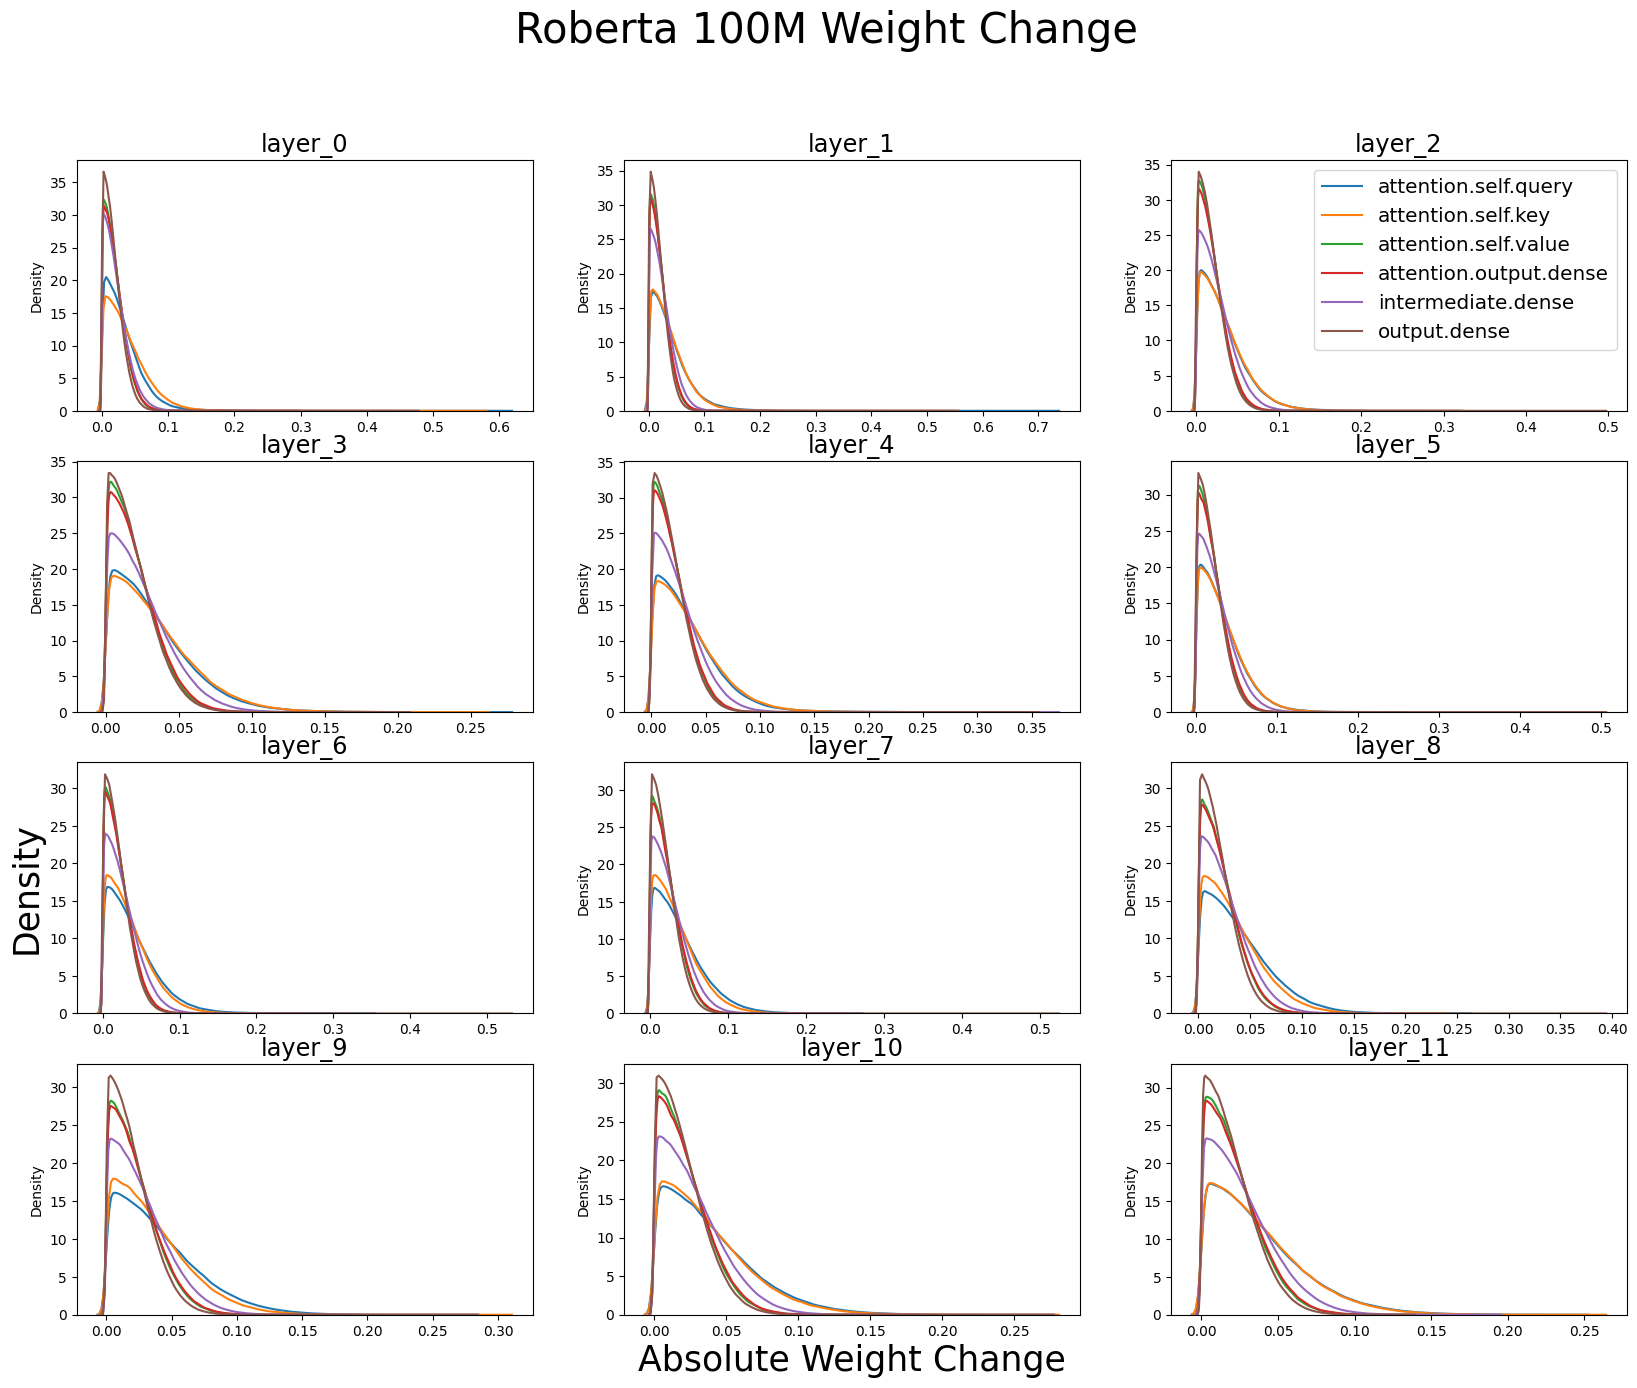

In [73]:
plot_lookup = [[0,0], [0,1], [0,2],
               [1,0], [1,1], [1,2],
               [2,0], [2,1], [2,2],
               [3,0], [3,1], [3,2]]

plot = "density"
log = True

f, axes = plt.subplots(4,3, figsize = (20,15))
#f.tight_layout()
plt.subplots_adjust(hspace = 0.2)
plt.suptitle("Roberta 100M Weight Change", fontsize = 30)
for idx, layer in enumerate(full_param_change):
    print(layer)
    row,col = plot_lookup[idx]
    l = layer.removeprefix("layer_")
    p = "roberta.encoder.layer."+l+"."
    for t in full_param_change[layer]:
        t_name = t.removeprefix(p)[:-7]
        #print(t_name)
        if plot == "density":
            data = [i for v in full_param_change[layer][t] for i in v]
            sns.kdeplot(data, ax=axes[row,col],label=t_name)
                
        if plot == "hist":
            data = [i for v in full_param_change[layer][t] for i in v]
            y, x = np.histogram(data, bins = 30)
            x = (x[:-1]+x[1:])/2
            if log == True:
                y = [np.log10(i+1) for i in y]
            axes[row,col].plot(x, y, label = t_name)
    axes[row,col].set_title(layer, fontsize = "xx-large")
    if idx == 10:
        axes[row,col].set_xlabel("Absolute Weight Change", fontsize = 25)
    if idx == 6:
        if plot == "density":
            axes[row,col].set_ylabel("Density", fontsize = 25)
        elif plot == "hist":
            if log == True:
                axes[row,col].set_ylabel("Log10 Counts", fontsize = 25)
            else:
                axes[row,col].set_ylabel("Raw Counts", fontsize = 25)
    if idx == 2:
        axes[row,col].legend(fontsize="x-large")
    # axes[row,col].legend()
    # axes[row,col].show(block = False)
fname = "roberta100M_weight_movement_density.pdf"
plt.savefig(fname, format = "pdf")

layer_0
layer_1
layer_2
layer_3
layer_4
layer_5
layer_6
layer_7
layer_8
layer_9
layer_10
layer_11


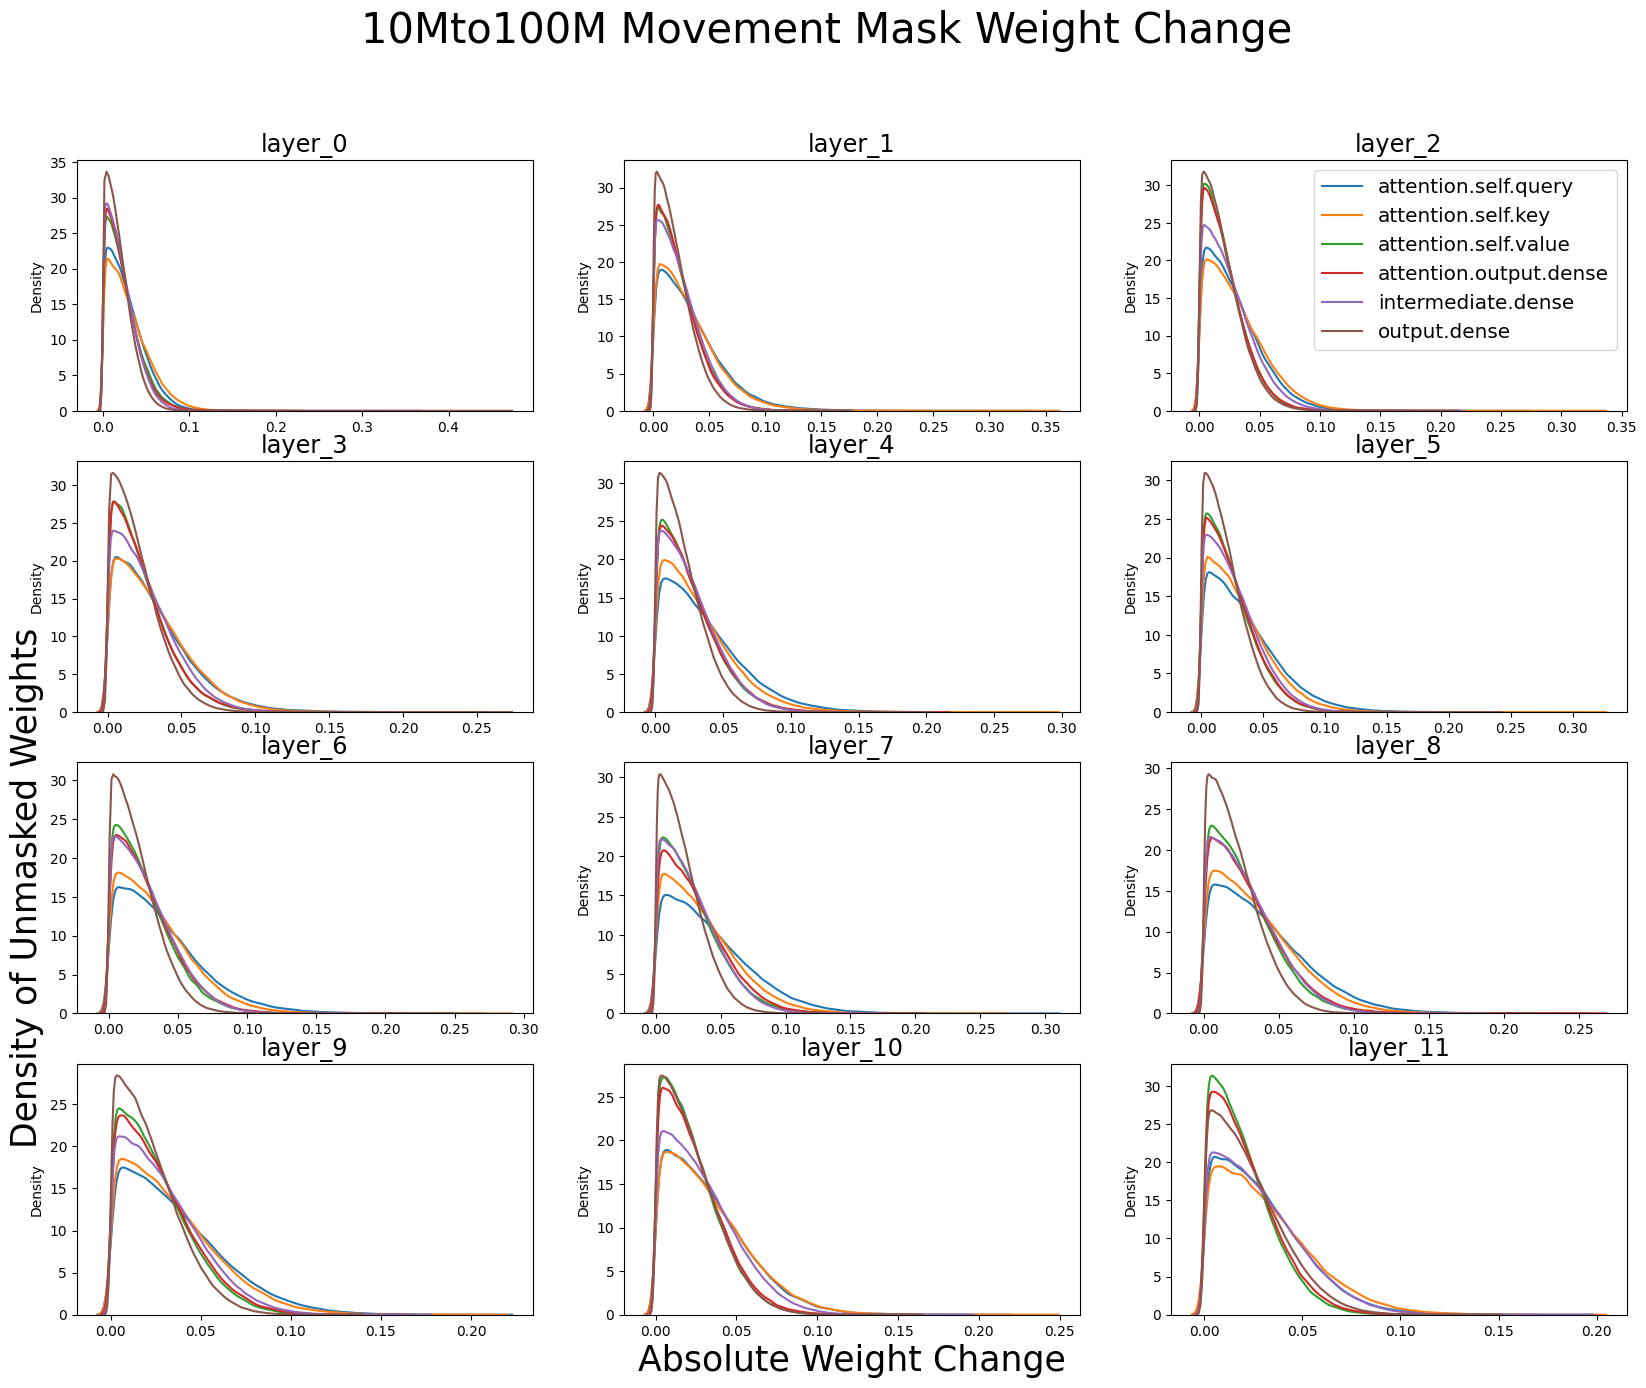

In [72]:
plot_lookup = [[0,0], [0,1], [0,2],
               [1,0], [1,1], [1,2],
               [2,0], [2,1], [2,2],
               [3,0], [3,1], [3,2]]

plot = "density"
log = True

f, axes = plt.subplots(4,3, figsize = (20,15))
#f.tight_layout()
plt.subplots_adjust(hspace = 0.2)
plt.suptitle("10Mto100M Movement Mask Weight Change", fontsize = 30)
for idx, layer in enumerate(mask_param_change):
    print(layer)
    row,col = plot_lookup[idx]
    l = layer.removeprefix("layer_")
    p = "roberta.encoder.layer."+l+"."
    for t in mask_param_change[layer]:
        t_name = t.removeprefix(p)[:-7]
        #print(t_name)
        if plot == "density":
            data = [i for v in mask_param_change[layer][t] for i in v]
            sns.kdeplot(data, ax=axes[row,col],label=t_name)
                
        if plot == "hist":
            data = [i for v in mask_param_change[layer][t] for i in v]
            y, x = np.histogram(data, bins = 30)
            x = (x[:-1]+x[1:])/2
            if log == True:
                y = [np.log10(i+1) for i in y]
            axes[row,col].plot(x, y, label = t_name)
    axes[row,col].set_title(layer, fontsize = "xx-large")
    if idx == 10:
        axes[row,col].set_xlabel("Absolute Weight Change", fontsize = 25)
    if idx == 6:
        if plot == "density":
            axes[row,col].set_ylabel("Density of Unmasked Weights", fontsize = 25)
        elif plot == "hist":
            if log == True:
                axes[row,col].set_ylabel("Log10 Counts of Unmasked Weights", fontsize = 25)
            else:
                axes[row,col].set_ylabel("Raw Counts of Unmasked Weights", fontsize = 25)
    if idx == 2:
        axes[row,col].legend(fontsize="x-large")
    # axes[row,col].legend()
    # axes[row,col].show(block = False)
fname = "10Mto100M_move_weight_movement_density.pdf"
plt.savefig(fname, format = "pdf")

## look at weight movement as % of initial weight instead of raw value

In [86]:
all_prop_move = dict()
for i in range(12):
    all_prop_move[f"layer_{i}"] = dict()
    for name, param in rob_100M.named_parameters():
        if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm" and (name[22:24] == str(i)+"." or name[22:25] == str(i)+"."):
            param_np = param.detach().numpy()
            init_param = rob_init.state_dict()[name].detach().numpy()
            param_change = (np.abs(init_param - param_np)/np.abs(init_param+5e-10))*100
            all_prop_move[f"layer_{i}"][name] = param_change

layer_0
layer_1
layer_2
layer_3
layer_4
layer_5
layer_6
layer_7
layer_8
layer_9
layer_10
layer_11


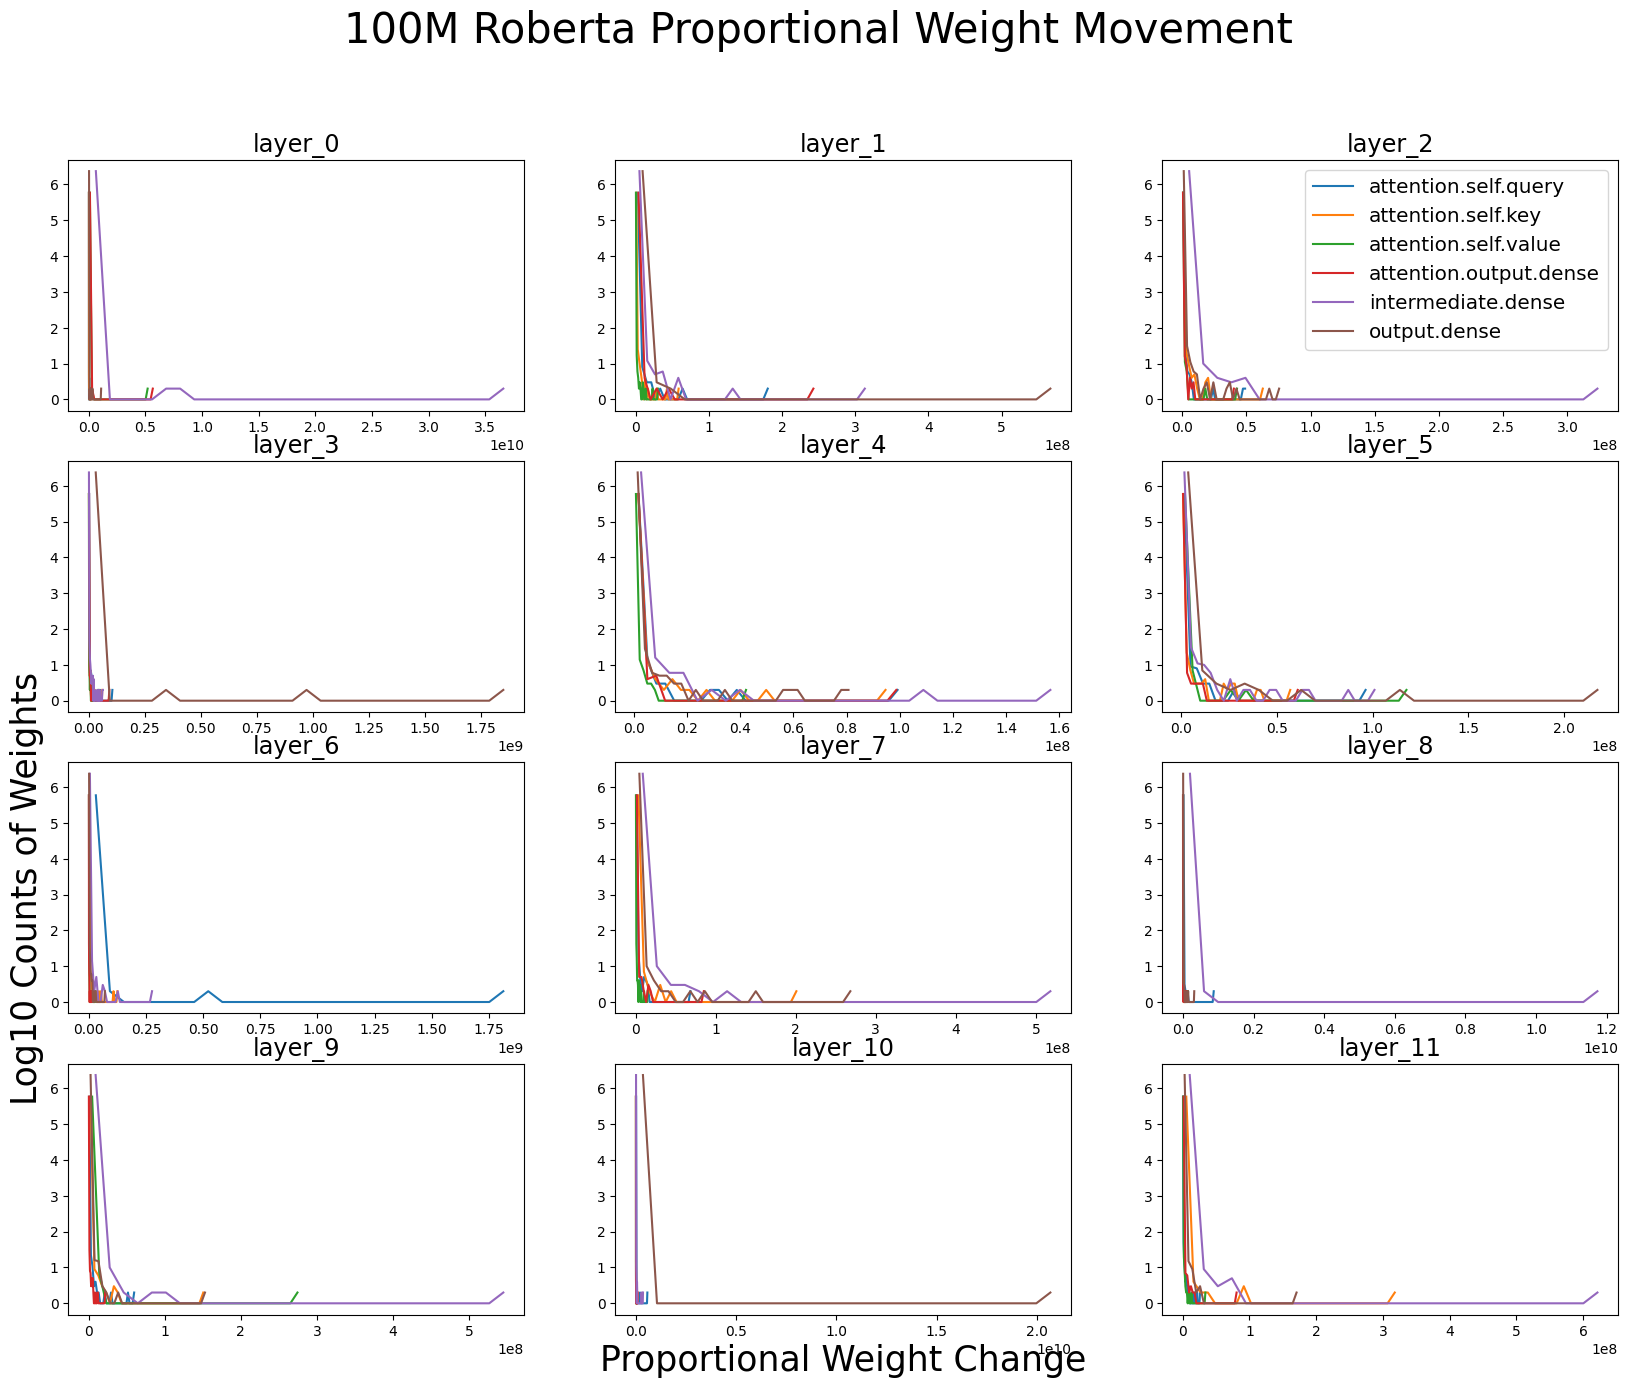

In [87]:
plot_lookup = [[0,0], [0,1], [0,2],
               [1,0], [1,1], [1,2],
               [2,0], [2,1], [2,2],
               [3,0], [3,1], [3,2]]

plot = "hist"
log = True

f, axes = plt.subplots(4,3, figsize = (20,15))
#f.tight_layout()
plt.subplots_adjust(hspace = 0.2)
plt.suptitle("100M Roberta Proportional Weight Movement", fontsize = 30)
for idx, layer in enumerate(all_prop_move):
    print(layer)
    row,col = plot_lookup[idx]
    l = layer.removeprefix("layer_")
    p = "roberta.encoder.layer."+l+"."
    for t in all_prop_move[layer]:
        t_name = t.removeprefix(p)[:-7]
        #print(t_name)
        if plot == "density":
            data = [i for v in all_prop_move[layer][t] for i in v]
            sns.kdeplot(data, ax=axes[row,col],label=t_name)
                
        if plot == "hist":
            data = [i for v in all_prop_move[layer][t] for i in v]
            y, x = np.histogram(data, bins = 30)
            x = (x[:-1]+x[1:])/2
            if log == True:
                y = [np.log10(i+1) for i in y]
            axes[row,col].plot(x, y, label = t_name)
    axes[row,col].set_title(layer, fontsize = "xx-large")
    if idx == 10:
        axes[row,col].set_xlabel("Proportional Weight Change", fontsize = 25)
    if idx == 6:
        if plot == "density":
            axes[row,col].set_ylabel("Density of Weights", fontsize = 25)
        elif plot == "hist":
            if log == True:
                axes[row,col].set_ylabel("Log10 Counts of Weights", fontsize = 25)
            else:
                axes[row,col].set_ylabel("Raw Counts of Weights", fontsize = 25)
    if idx == 2:
        axes[row,col].legend(fontsize="x-large")
    # axes[row,col].legend()
    # axes[row,col].show(block = False)
fname = "10M_prop_weight_movement_density.pdf"
plt.savefig(fname, format = "pdf")

In [51]:
all_move_mask = []
for name, param in model.named_parameters():
    if name[8:15] == "encoder" and name[-6:] == "weight" and name[-16:-7] != "LayerNorm":
        init_param = init_model.state_dict()[name]
        param_change = torch.abs(init_param-param)
        cutoff = torch.quantile(param_change, cutoff_perc)
        move_mask = param_change > cutoff
        all_move_mask.append(move_mask)

# Check model train progress for different init

In [3]:
m1_init = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_init2")
m2_init = RobertaForMaskedLM.from_pretrained("/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_init3")
m1 = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_10M_init2/epoch_20")
m2 = RobertaForMaskedLM.from_pretrained("/media/easystore/initialization_all_epochs/roberta_10M_init3/epoch_20")

In [5]:
for name, param in m1.named_parameters():
    if "encoder" in name and "weight" in name and "LayerNorm" not in name:
        print(name)
        pi = m1_init.state_dict()[name].data
        print(param.data == pi)

roberta.encoder.layer.0.attention.self.query.weight
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])
roberta.encoder.layer.0.attention.self.key.weight
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])
roberta.encoder.layer.0.attention.self.value.weight
tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
      

In [7]:
for name, param in m2.named_parameters():
    if "encoder" in name and "weight" in name and "LayerNorm" not in name:
        print(name)
        pi = m2_init.state_dict()[name].data
        print(param.data)

roberta.encoder.layer.0.attention.self.query.weight
tensor([[-0.0348,  0.0439,  0.0012,  ..., -0.0120,  0.0062, -0.0252],
        [-0.0226, -0.0044, -0.0127,  ..., -0.0210,  0.0121,  0.0012],
        [ 0.0075, -0.0251,  0.0050,  ..., -0.0291,  0.0110, -0.0094],
        ...,
        [ 0.0201,  0.0050, -0.0015,  ...,  0.0119,  0.0144, -0.0157],
        [-0.0041,  0.0184,  0.0210,  ...,  0.0348, -0.0159,  0.0062],
        [-0.0044, -0.0110, -0.0152,  ..., -0.0147,  0.0372,  0.0064]])
roberta.encoder.layer.0.attention.self.key.weight
tensor([[ 0.0118,  0.0166, -0.0283,  ..., -0.0177,  0.0056, -0.0086],
        [-0.0113,  0.0227, -0.0219,  ...,  0.0341,  0.0002,  0.0069],
        [-0.0257, -0.0174, -0.0546,  ..., -0.0210,  0.0002,  0.0098],
        ...,
        [-0.0112,  0.0122, -0.0009,  ...,  0.0142, -0.0178, -0.0228],
        [-0.0165, -0.0075, -0.0030,  ..., -0.0274,  0.0116, -0.0004],
        [-0.0243, -0.0188,  0.0110,  ...,  0.0093, -0.0200, -0.0047]])
roberta.encoder.layer.0.attent